# RAG + Eval Pipeline

**Goal:** Production/research-grade RAG over AI papers + engineering blogs.
After this notebook you can:
1. Build end-to-end RAG pipelines independently at a startup
2. Critically read RAG research papers (know what eval claims are valid)
3. Contribute to RAG research — understand open problems and how to measure progress

**Corpus:** ~14 arXiv papers + ~5 engineering blog posts
**Stack:** BGE-M3 (local embeddings) · ChromaDB · BM25 + hybrid RRF · BGE-reranker · GPT-4o-mini · RAGAS · HotpotQA

```
Papers + Blogs → chunk → BGE-M3 → ChromaDB
                                       ↓
Query → BM25 + dense → hybrid RRF → rerank → GPT-4o-mini → RAGAnswer
                                                                 ↓
                         HotpotQA recall@k · RAGAS · LLM-as-Judge bias analysis
```


## Part 1 — Data Ingestion & Chunking

### Why chunking determines retrieval quality

A RAG system retrieves *chunks*, not documents. The chunk is the atomic unit of retrieval.

**Chunk too large:** one chunk covers multiple topics → retrieved for wrong queries → low precision 

**Chunk too small:** one sentence per chunk → multi-sentence answers need many chunks → low recall

The correct size depends on your queries. For dense technical text (research papers), semantic chunking
to ≤512 tokens balances both.

**Semantic chunking algorithm:**
1. Split text into sentences on punctuation boundaries
2. Greedily merge sentences until the next would exceed `max_tokens`
3. Flush the buffer as a chunk; start a new buffer

**Why 512 tokens?** BGE-M3 was trained on sequences up to 8192 tokens, but embedding quality degrades
for long sequences. 512 tokens (~380 words) captures a complete idea without diluting the vector.

Paper: [BGE-M3 (Chen et al. 2024)](https://arxiv.org/abs/2402.03216)


### Written Question 1

*Why does chunking matter more for multi-hop questions than single-hop? Give a concrete example where
an answer requires one passage from a paper and one from a blog post. What chunk size would you choose
and why?*


In [1]:
import sys
sys.path.insert(0, '../src')
from rag.ingest import Chunk, chunk_document, load_pdf, load_html
from pathlib import Path

pdf_path = '../data/papers/rag_lewis2020.pdf'
if Path(pdf_path).exists():
    text = load_pdf(pdf_path)
    print(f"Extracted {len(text):,} characters")
    print(f"\nPreview (first 500 chars):\n{text[:500]}")
else:
    print("Run: python scripts/download_papers.py")


Extracted 69,076 characters

Preview (first 500 chars):
Retrieval-Augmented Generation for
Knowledge-Intensive NLP Tasks
Patrick Lewis†‡, Ethan Perez⋆,
Aleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,
Mike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†
†Facebook AI Research;‡University College London;⋆New York University;
plewis@fb.com
Abstract
Large pre-trained language models have been shown to store factual knowledge
in their parameters, and achieve state-of-the-art results when ﬁ


In [2]:
if Path(pdf_path).exists():
    meta = {
        "source_type": "paper",
        "company": "Meta",
        "topic_tag": "RAG",
        "pub_date": "2020-05-22",
        "url": "https://arxiv.org/abs/2005.11401",
        "source_title": "RAG — Lewis et al. 2020",
    }
    chunks = chunk_document(text, meta, max_tokens=512)
    print(f"Total chunks: {len(chunks)}")
    avg_words = sum(len(c.text.split()) for c in chunks) / len(chunks)
    print(f"Avg length (words): {avg_words:.0f}")
    print(f"\nChunk 5:\n{chunks[5].text[:300]}...")


Total chunks: 38
Avg length (words): 260

Chunk 5:
We use
a pre-trained bi-encoder from DPR to initialize our retriever and to build the document index. This
retriever was trained to retrieve documents which contain answers to TriviaQA [24] questions and
Natural Questions [29]. We refer to the document index as the non-parametric memory. 2.3 Generat...


In [3]:
# Test: all chunks ≤ 512 tokens, non-empty
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")
if Path(pdf_path).exists():
    bad = [c for c in chunks if len(enc.encode(c.text)) > 512]
    assert not bad, f"{len(bad)} chunks exceed 512 tokens"
    assert all(c.text.strip() for c in chunks)
    print(f"✓ All {len(chunks)} chunks valid (≤512 tokens, non-empty)")


✓ All 38 chunks valid (≤512 tokens, non-empty)


## Part 2 — Embedding & Vector Store

### Dense vs Sparse: why neither alone is enough

**Sparse (BM25):** bag-of-words, score = weighted term overlap
✓ exact keyword match, fast, interpretable
✗ vocabulary mismatch: "car" ≠ "automobile", no semantic understanding

**Dense (BGE-M3):** neural encoder, score = cosine similarity of embedding vectors
✓ semantic understanding, handles paraphrases
✗ needs trained model, slower, harder to debug

Neither alone is sufficient — we combine them in Part 3.

### Why BGE-M3 over OpenAI embeddings?

[BGE-M3 (Chen et al. 2024)](https://arxiv.org/abs/2402.03216) from BAAI:
- **Free to run locally** — no per-token API cost (critical when indexing 50+ papers)
- SOTA on MTEB benchmark for technical/scientific text
- Produces dense, sparse (lexical), AND multi-vector representations simultaneously
- Supports 8192-token sequences natively

Embedding dimension: **1024** (dense). Stored in ChromaDB with cosine similarity.

ChromaDB uses approximate nearest-neighbor search (HNSW graph) for fast retrieval.
For our corpus size (~3000 chunks), exact search would also be fine — HNSW matters at scale.


### Written Question 2

*BM25 uses IDF (inverse document frequency) to downweight common terms. In a corpus of 14 AI papers,
which specific terms would have near-zero IDF? Why would retrieval fail for a query like
"attention mechanism" without IDF weighting?*


In [4]:
from rag.ingest import load_pdf, load_html, chunk_document
from pathlib import Path

all_chunks = []

# Load papers
for pdf in sorted(Path('../data/papers').glob('*.pdf')):
    try:
        text = load_pdf(str(pdf))
        meta = {
            "source_type": "paper",
            "source_title": pdf.stem.replace('_', ' '),
            "company": "arXiv",
            "topic_tag": "AI",
            "url": "",
        }
        c = chunk_document(text, meta)
        all_chunks.extend(c)
        print(f"  {pdf.name}: {len(c)} chunks")
    except Exception as e:
        print(f"  SKIP {pdf.name}: {e}")

# Load blogs
for txt in sorted(Path('../data/blogs').glob('*.txt')):
    try:
        text = txt.read_text(encoding='utf-8')
        meta = {"source_type": "blog", "source_title": txt.stem.replace('_', ' '),
                "company": "unknown", "topic_tag": "engineering", "url": ""}
        for line in text.split('\n')[:5]:
            if line.startswith('# COMPANY:'): meta['company'] = line.split(':',1)[1].strip()
            elif line.startswith('# TOPIC:'): meta['topic_tag'] = line.split(':',1)[1].strip()
            elif line.startswith('# SOURCE:'): meta['url'] = line.split(':',1)[1].strip()
        c = chunk_document(text, meta)
        all_chunks.extend(c)
        print(f"  {txt.name}: {len(c)} chunks")
    except Exception as e:
        print(f"  SKIP {txt.name}: {e}")

print(f"\nTotal: {len(all_chunks)} chunks from {len(list(Path('../data/papers').glob('*.pdf')))} papers + {len(list(Path('../data/blogs').glob('*.txt')))} blogs")


  bge_m3_chen2024.pdf: 50 chunks
  dpo_rafailov2023.pdf: 54 chunks
  frames_krishna2024.pdf: 24 chunks
  hotpotqa_yang2018.pdf: 25 chunks
  hyde_gao2022.pdf: 27 chunks
  instructgpt_ouyang2022.pdf: 102 chunks
  llm_judge_zheng2023.pdf: 47 chunks
  rag_lewis2020.pdf: 38 chunks
  ragas_es2023.pdf: 17 chunks
  raptor_sarthi2024.pdf: 42 chunks
  react_yao2022.pdf: 73 chunks
  self_rag_asai2023.pdf: 56 chunks
  speculative_decoding.pdf: 31 chunks
  vllm_kwon2023.pdf: 46 chunks
  blog_vllm_ai_2023_06_20_vllm_html.txt: 4 chunks
  cohere_com_blog_rerank.txt: 1 chunks
  huggingface_co_blog_dpo_trl.txt: 6 chunks
  huggingface_co_blog_evaluation_structured_outputs.txt: 7 chunks
  www_anthropic_com_news_contextual_retrieval.txt: 7 chunks

Total: 657 chunks from 14 papers + 5 blogs


In [5]:
from rag.embed import embed_and_store, load_collection

print("Embedding with BGE-M3 (first run downloads ~2GB)...")
collection = embed_and_store(all_chunks, "rag_corpus", persist_dir="../data/chroma")
print(f"\n✓ {collection.count()} chunks stored in ChromaDB")


Embedding with BGE-M3 (first run downloads ~2GB)...


Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Inference Embeddings: 100%|██████████| 15/15 [00:02<00:00,  6.21it/s]



✓ 828 chunks stored in ChromaDB


In [6]:
# Sanity check: query the collection
results = collection.query(
    query_texts=["How does speculative decoding reduce inference latency?"],
    n_results=3,
)
print("Top 3 results for 'How does speculative decoding reduce inference latency?'\n")
for i, (doc, meta) in enumerate(zip(results['documents'][0], results['metadatas'][0])):
    print(f"[{i+1}] {meta.get('source_title','?')[:50]} ({meta.get('source_type')})")
    print(f"     {doc[:150]}...\n")


Top 3 results for 'How does speculative decoding reduce inference latency?'

[1] ? (paper)
     when memory bandwidth is the bottleneck) our method
provides the speedup with signiﬁcant beneﬁts: the model
architecture doesn’t change, retraining is...

[2] ? (paper)
     Fast Inference from Transformers via Speculative Decoding
Yaniv Leviathan* 1 Matan Kalman * 1 Yossi Matias1
Abstract
Inference from large autoregressi...

[3] ? (paper)
     Copyright
2023 by the author(s). developed to make inference from them faster. Some ap-
proaches aim to reduce the inference cost for all inputs
equal...



## Part 3 — Retrieval Ablation

### Hybrid Retrieval with Reciprocal Rank Fusion (RRF)

**The failure modes:**
- BM25 fails on semantic queries: "what causes hallucination" won't match "factual errors from LLMs"
- Dense fails on exact-match queries: "what is DPO" may return similar-sounding but wrong passages

**RRF ([Cormack et al. 2009](https://dl.acm.org/doi/10.1145/1571941.1572114)):**

$$\text{RRF}(d) = \sum_{r \in \{\text{bm25, dense}\}} \frac{1}{k + \text{rank}_r(d)}$$

$k=60$ is a smoothing constant. Without it, rank-1 from either retriever dominates.
With $k=60$, rank-1 contributes $1/61 \approx 0.016$ — moderated.
Documents ranked highly by *both* retrievers win. This is the key insight.

### Cross-Encoder Reranking

Bi-encoder (BM25, dense): encodes query and document *separately*
Cross-encoder (BGE-reranker): encodes [query, document] *together* — full attention over both

[BGE-reranker-v2-m3](https://huggingface.co/BAAI/bge-reranker-v2-m3): much higher precision,
but can't pre-compute — used only on top candidates (e.g. top-20 → rerank → top-5).

### HotpotQA Retrieval Benchmark

[HotpotQA (Yang et al. 2018)](https://arxiv.org/abs/1809.09600) — gold-standard multi-hop QA.
We use it to benchmark the retrieval component in isolation (HotpotQA uses its own Wikipedia corpus).
This gives a recall@k number we can compare against published RAG papers.

Why not BEIR? BEIR ([Thakur et al. 2021](https://arxiv.org/abs/2104.08663)) benchmarks retrieval
in isolation. HotpotQA specifically tests multi-hop reasoning — more realistic for our use case.
FRAMES ([Krishna et al. 2024](https://arxiv.org/abs/2409.12941)) goes further and tests the full
pipeline (factuality + retrieval + reasoning) — the gold standard if you want end-to-end comparability.


### Written Question 3

*The RRF formula uses `1/(k+rank)` rather than raw retrieval scores. What would go wrong if you
naively summed `score_bm25 + score_dense`? Give a numerical example showing why scale mismatch matters.*


In [7]:
from rag.retrieve import bm25_retrieve, dense_retrieve, hybrid_rrf, rerank

QUERY = "How does speculative decoding reduce LLM inference latency?"

dense_r  = dense_retrieve(QUERY, collection, k=10)
bm25_r   = bm25_retrieve(QUERY, all_chunks, k=10)
hybrid_r = hybrid_rrf(bm25_r, dense_r)
rerank_r = rerank(QUERY, hybrid_r, top_k=5)

strategies = {
    "dense":    dense_r[:5],
    "bm25":     bm25_r[:5],
    "hybrid":   hybrid_r[:5],
    "reranked": rerank_r,
}
for name, results in strategies.items():
    print(f"\n=== {name} ===")
    for r in results:
        print(f"  [{r.score:.4f}] {r.metadata.get('source_title','?')[:45]}")
        print(f"           {r.text[:90]}...")


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


=== dense ===
  [0.2920] ?
           Fast Inference from Transformers via Speculative Decoding
Yaniv Leviathan* 1 Matan Kalman ...
  [0.2893] ?
           when memory bandwidth is the bottleneck) our method
provides the speedup with signiﬁcant b...
  [0.2286] ?
           In this work, we generalize
speculative execution to the stochastic setting - where a
task...
  [0.2090] ?
           Likewise the middle row shows speculative decoding withγ = 3,
and the bottom row shows sta...
  [0.1835] ?
           They usually also change the
outputs of the model. We note that while many of the meth-
od...

=== bm25 ===
  [16.3832] speculative decoding
           They usually also change the
outputs of the model. We note that while many of the meth-
od...
  [15.1739] vllm kwon2023
           These
systems utilize GPU kernel optimizations [1, 29, 31, 56], ad-
vanced batching mechan...
  [14.8136] speculative decoding
           when memory bandwidth is the bottleneck) our method
provides the spe

In [8]:
# Ablation: recall@k on HotpotQA subset
from rag.eval.retrieval_bench import load_hotpotqa_subset, run_retrieval_benchmark
import pandas as pd

print("Loading HotpotQA subset (50 questions for speed)...")
samples = load_hotpotqa_subset(n=50)
print(f"Loaded {len(samples)} samples")
print(f"Example: {samples[0].question}")

retrieve_fns = {
    "BM25":          lambda q, k: bm25_retrieve(q, all_chunks, k),
    "Dense":         lambda q, k: dense_retrieve(q, collection, k),
    "Hybrid RRF":    lambda q, k: hybrid_rrf(bm25_retrieve(q, all_chunks, k), dense_retrieve(q, collection, k)),
    "Hybrid+Rerank": lambda q, k: rerank(q, hybrid_rrf(bm25_retrieve(q, all_chunks, k), dense_retrieve(q, collection, k)), top_k=k),
}

ablation_rows = {}
for name, fn in retrieve_fns.items():
    print(f"Running {name}...")
    ablation_rows[name] = run_retrieval_benchmark(samples, all_chunks, fn)

df_ablation = pd.DataFrame(ablation_rows).T
print("\n=== Ablation Table (HotpotQA, Recall@k) ===")
print(df_ablation.to_string(float_format="{:.3f}".format))


Loading HotpotQA subset (50 questions for speed)...
Loaded 50 samples
Example: Were Scott Derrickson and Ed Wood of the same nationality?
Running BM25...
Running Dense...
Running Hybrid RRF...
Running Hybrid+Rerank...

=== Ablation Table (HotpotQA, Recall@k) ===
               recall@3  recall@5  recall@10
BM25              0.000     0.000      0.000
Dense             0.000     0.000      0.000
Hybrid RRF        0.000     0.000      0.000
Hybrid+Rerank     0.000     0.000      0.000


## Part 4 — Structured Answer Generation

### Why free-text generation fails in production

Raw LLM output is a string. At scale:
- Citations are inconsistent or missing
- Confidence is never quantified
- Downstream parsing is brittle

**Structured outputs** (OpenAI JSON mode + [instructor](https://github.com/jxnl/instructor)):
Force the LLM to return a validated Pydantic schema. If validation fails, instructor
sends the error back to the LLM and retries (`max_retries=2`). Output is always parseable.

### Schema design

```python
class Citation(BaseModel):
    source_title: str; source_type: str  # "paper" | "blog"
    company: str; url: str; relevant_excerpt: str

class RAGAnswer(BaseModel):
    answer: str
    citations: list[Citation]
    confidence: float          # 0.0 (no relevant context) → 1.0 (directly answered)
    reasoning_steps: list[str] # explicit chain-of-thought for multi-hop
```

`reasoning_steps` forces explicit chain-of-thought for multi-hop questions —
improves accuracy AND makes evaluation easier (check each step independently).

### Difference between JSON mode, function calling, and response_model

- **JSON mode**: LLM outputs any valid JSON. No schema enforcement. Parsing can still fail.
- **Function calling**: LLM fills in a function schema. Stronger guarantee, widely supported.
- **response_model (instructor)**: Wraps function calling + Pydantic validation + auto-retry.
  Strongest guarantee — invalid outputs trigger retries with the validation error in context.


### Written Question 4

*What is the difference between OpenAI's JSON mode, function calling, and `response_model`
(instructor)? Which gives the strongest schema guarantee? When would you use function calling
over a response_model?*


In [10]:
import os
from openai import OpenAI
from rag.generate import generate_answer, RAGAnswer

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

QUERY = "How does speculative decoding reduce LLM inference latency, and has any company deployed this?"
ans = generate_answer(QUERY, rerank_r, client)

print(f"Answer:\n{ans.answer}")
print(f"\nConfidence: {ans.confidence:.2f}")
print(f"\nReasoning steps:")
for step in ans.reasoning_steps:
    print(f"  - {step}")
print(f"\nCitations ({len(ans.citations)}):")
for c in ans.citations:
    print(f"  [{c.source_type}] {c.source_title} — {c.url}")
    print(f"  Excerpt: {c.relevant_excerpt[:100]}...")


Answer:
Speculative decoding reduces LLM inference latency by allowing several tokens to be decoded in parallel instead of serially. This method utilizes approximation models to generate speculative preﬁxes that are accepted by the target model, leading to a speedup of about 2X-3X compared to standard implementations without changing the output distribution. The technique is suitable for use with existing off-the-shelf models, does not require retraining, and can be easily implemented in production settings (source [5]).  

Regarding deployment, the context does not specify a particular company that has implemented speculative decoding, but mentions that the method has been demonstrated on T5-XXL and achieved substantial speedups in practice (source [2]).

Confidence: 0.80

Reasoning steps:
  - Identified the mechanism of speculative decoding from the context, specifically its ability to compute several tokens in parallel to reduce latency.
  - Referenced the performance improvements d

In [11]:
# Test: 5 queries all parse to RAGAnswer
import time

TEST_QUERIES = [
    "What is RAG and why does it reduce hallucination?",
    "How does DPO differ from RLHF?",
    "Why does BM25 fail on semantic queries?",
    "What is the acceptance rate in speculative decoding?",
    "What is context precision in RAGAS?",
]

failures = []
for q in TEST_QUERIES:
    try:
        r = rerank(q, hybrid_rrf(
            bm25_retrieve(q, all_chunks, 10),
            dense_retrieve(q, collection, 10)
        ), top_k=5)
        a = generate_answer(q, r, client)
        assert isinstance(a, RAGAnswer)
        assert 0.0 <= a.confidence <= 1.0
        print(f"✓ {q[:65]}")
        time.sleep(0.5)
    except Exception as e:
        failures.append(q)
        print(f"✗ {q[:65]}: {e}")

print(f"\n{len(TEST_QUERIES) - len(failures)}/{len(TEST_QUERIES)} parsed successfully")


✓ What is RAG and why does it reduce hallucination?
✓ How does DPO differ from RLHF?
✓ Why does BM25 fail on semantic queries?
✓ What is the acceptance rate in speculative decoding?
✓ What is context precision in RAGAS?

5/5 parsed successfully


## Part 5 — RAGAS End-to-End Evaluation

### What each metric measures (and why the definition is the way it is)

[RAGAS (Es et al. 2023)](https://arxiv.org/abs/2309.15217) — reference-free RAG evaluation.
"Reference-free" = no human-annotated answers needed. An LLM judges quality.

**faithfulness** — fraction of claims in the answer supported by the context
*Why this definition:* hallucination = claim not in context. Count unsupported claims.
*Failure mode:* lenient judge lets paraphrased hallucinations through.

**answer_relevancy** — mean cosine similarity between the question and N reverse-engineered questions
from the answer.
*Why this definition:* "does this answer the question?" is subjective. Reverse-engineering is objective.
*Failure mode:* verbose answers that mention the topic but don't answer score high.

**context_recall** — fraction of ground-truth answer sentences attributable to retrieved context.
*Requires ground_truth.* This is why we need the synthetic testset.

**context_precision** — fraction of retrieved chunks that are actually useful.
*Why it matters:* irrelevant context = noise + wasted tokens + confusion for the LLM.

### Why RAGAS synthetic testset generation?

We use RAGAS `TestsetGenerator` to generate QA pairs from our own corpus.
This is necessary because standard benchmarks (HotpotQA, FRAMES) use their own corpora —
they can't measure whether our chunking/embedding works on *our* documents.

RAGAS generates 3 question types:
- **simple** (40%): single-hop, directly answerable from one passage
- **reasoning** (30%): requires inference beyond the literal text
- **multi_context** (30%): answer requires multiple passages (tests multi-hop retrieval)

**Always spot-check ~15 questions manually.** Generator can produce bad questions.
Protocol: for each, answer (1) Is this realistic? (2) Is the ground truth correct? (3) Is the type label right?


In [12]:
from rag.eval.ragas_eval import generate_testset

print("Generating 20 synthetic QA pairs with RAGAS TestsetGenerator...")
print("(Calls OpenAI API — expect ~$0.20 and ~2 min)\n")

corpus_texts = [c.text for c in all_chunks[:100]]  # limit for speed
testset = generate_testset(corpus_texts, n=20)

print(f"Generated {len(testset)} QA pairs")
import pandas as pd
df_ts = pd.DataFrame(testset)
if 'evolution_type' in df_ts.columns:
    print("\nType distribution:")
    print(df_ts['evolution_type'].value_counts())
print("\nSample questions:")
for row in testset[:3]:
    print(f"  Q: {str(row.get('question',''))[:80]}")


Generating 20 synthetic QA pairs with RAGAS TestsetGenerator...
(Calls OpenAI API — expect ~$0.20 and ~2 min)



embedding nodes:   0%|          | 0/200 [00:00<?, ?it/s]

Filename and doc_id are the same for all nodes.


Generating:   0%|          | 0/20 [00:00<?, ?it/s]

max retries exceeded for ReasoningEvolution(generator_llm=LangchainLLMWrapper(run_config=RunConfig(timeout=180, max_retries=15, max_wait=90, max_workers=16, exception_types=<class 'openai.RateLimitError'>, log_tenacity=False, seed=42)), docstore=InMemoryDocumentStore(splitter=<langchain_text_splitters.base.TokenTextSplitter object at 0x71d12112a960>, nodes=[Node(page_content='M3-Embedding: Multi-Linguality, Multi-Functionality, Multi-Granularity\nText Embeddings Through Self-Knowledge Distillation\nJianlv Chen♣ Shitao Xiao♠† Peitian Zhang♠ Kun Luo♠ Defu Lian♣∗ Zheng Liu♠∗\n♣ University of Science and Technology of China ♠ BAAI\nstxiao@baai.ac.cn{namespace.pt,luokun695,zhengliu1026}@gmail.com\nchenjianlv@mail.ustc.edu.cn liandefu@ustc.edu.cn\nAbstract\nIn this paper, we introduce a new embedding\nmodel calledM3-Embedding, which is distin-\nguished for its versatility inMulti-Linguality,\nMulti-Functionality, andMulti-Granularity. It\nprovides a uniform support for the semantic re-\ntrie

Generated 19 QA pairs

Type distribution:
evolution_type
simple           8
multi_context    6
reasoning        5
Name: count, dtype: int64

Sample questions:
  Q: What is the significance of PPO optimization in the context of reward maximizati
  Q: What is the significance of the DPO objective in the context of optimizing rewar
  Q: What does the comparison of DPO and PPO performance reveal about their effective


### Can we trust this testset?

Spot-check protocol: review 10 questions below. For each, annotate:
1. Realistic? (Y/N)
2. Ground truth correct? (Y/N)
3. Type label right? (Y/N)

If >30% fail any criterion, regenerate with a better model or filter.


In [13]:
import random
random.seed(42)
spot = random.sample(testset, min(10, len(testset)))
for i, s in enumerate(spot[:5]):
    print(f"[{i+1}] Q: {str(s.get('question',''))[:80]}")
    print(f"     GT: {str(s.get('ground_truth',''))[:100]}")
    print(f"     Type: {s.get('evolution_type','?')}")
    print(f"     ANNOTATE: realistic? __  GT correct? __  type correct? __\n")


[1] Q: What is the significance of neural text generation in the context of artificial 
     GT: The answer to given question is not present in context
     Type: simple
     ANNOTATE: realistic? __  GT correct? __  type correct? __

[2] Q: What is the significance of PPO optimization in the context of reward maximizati
     GT: The significance of PPO optimization in the context of reward maximization and policy conservativene
     Type: simple
     ANNOTATE: realistic? __  GT correct? __  type correct? __

[3] Q: What links KL-constrained RL, reward funcs, and optimal models?
     GT: The context does not provide a direct answer to the question about the links between KL-constrained 
     Type: reasoning
     ANNOTATE: realistic? __  GT correct? __  type correct? __

[4] Q: What does the evaluation of multilingual long-doc retrieval on the MLDR test set
     GT: The evaluation of multilingual long-doc retrieval on the MLDR test set measures performance using nD
     Type: simple
    

In [14]:
from rag.eval.ragas_eval import run_ragas_eval

def retrieve_fn(q, k=5):
    return rerank(
        q,
        hybrid_rrf(bm25_retrieve(q, all_chunks, k*2), dense_retrieve(q, collection, k*2)),
        top_k=k,
    )

def generate_fn(q, results):
    return generate_answer(q, results, client)

print("Running RAGAS eval (Hybrid + Rerank strategy)...")
print("(Calls OpenAI API — expect ~$0.50 and ~3 min)\n")
ragas_scores = run_ragas_eval(testset[:15], retrieve_fn, generate_fn)

print("\n=== RAGAS Scores (Hybrid + Rerank) ===")
for metric, score in ragas_scores.items():
    bar = "█" * int(score * 20)
    print(f"  {metric:<25} {score:.3f}  {bar}")


Running RAGAS eval (Hybrid + Rerank strategy)...
(Calls OpenAI API — expect ~$0.50 and ~3 min)



Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]


=== RAGAS Scores (Hybrid + Rerank) ===
  faithfulness              0.895  █████████████████
  answer_relevancy          0.968  ███████████████████
  context_recall            1.000  ████████████████████
  context_precision         0.468  █████████


## Part 6 — LLM-as-Judge: Building Trust in Your Evaluator

### What LLM-as-Judge is and why startups use it

Use an LLM to evaluate the output of another LLM.

**Why it's the primary eval method at startups:**
- Human eval: $5-50/question, days to weeks
- LLM judge: ~$0.01/question, seconds, ~80% agreement with human experts (see paper below)
- Consistent: same answer always gets same score

### Two known biases ([Zheng et al. 2023, MT-Bench paper](https://arxiv.org/abs/2306.05685))

**1. Positional bias:** LLM judges prefer the *first* answer in A-vs-B comparison ~65% of the time.
*Mitigation:* Run each comparison twice (A-first, B-first). Average scores. Call it a tie if winner flips.
*Threshold:* flip rate > 15% = significant bias.

**2. Length bias:** LLMs assign higher scores to longer answers regardless of quality.
*Mitigation:* Measure Pearson r between answer length and score. If |r| > 0.3, add verbosity penalty.

### Our rubric (point scoring, not comparative — avoids positional bias in primary eval)

```
relevance:     0–3  (does the answer address the question?)
faithfulness:  0–3  (is every claim grounded in context?)
completeness:  0–3  (are all answerable aspects covered?)
total:         0–9  → normalized to 0.0–1.0
```

Point scoring avoids the A-vs-B comparison entirely. We use comparison only in the bias check.


### Written Question 5

*In MT-Bench, GPT-4 achieves ~80% agreement with human experts on single-answer grading.
What does the remaining 20% disagreement tell you about using LLM-as-judge for high-stakes
decisions? What systematic errors does the judge make most often? (Cite the paper.)*


In [15]:
from rag.eval.judge import llm_judge, positional_bias_check, length_correlation_check
import time

# Generate answer pairs: naive dense vs hybrid+rerank
test_qs = [str(s.get('question','')) for s in testset[:6]]
contexts_list, answers_naive, answers_reranked = [], [], []

for q in test_qs:
    naive = dense_retrieve(q, collection, k=5)
    reranked = retrieve_fn(q)
    a_naive = generate_answer(q, naive, client)
    a_reranked = generate_answer(q, reranked, client)
    answers_naive.append(a_naive.answer)
    answers_reranked.append(a_reranked.answer)
    contexts_list.append(" ".join(r.text for r in naive[:3]))
    time.sleep(0.3)

print(f"Generated {len(test_qs)} answer pairs (naive dense vs hybrid+rerank)")


Generated 6 answer pairs (naive dense vs hybrid+rerank)


In [16]:
# Score each answer
naive_scores, reranked_scores = [], []
for q, a_n, a_r, ctx in zip(test_qs, answers_naive, answers_reranked, contexts_list):
    naive_scores.append(llm_judge(q, a_n, ctx, client))
    reranked_scores.append(llm_judge(q, a_r, ctx, client))
    time.sleep(0.3)

n_mean = sum(r.score for r in naive_scores) / len(naive_scores)
r_mean = sum(r.score for r in reranked_scores) / len(reranked_scores)
print(f"Naive dense mean score:    {n_mean:.3f}")
print(f"Hybrid+rerank mean score:  {r_mean:.3f}")
print(f"Improvement:               {r_mean - n_mean:+.3f}")


Naive dense mean score:    0.963
Hybrid+rerank mean score:  1.000
Improvement:               +0.037


In [18]:
# Positional bias check
print("=== Positional Bias Check ===")
print("Running each comparison A-first and B-first (4x API calls per pair)...")
pairs = list(zip(answers_naive[:3], answers_reranked[:3]))
bias = positional_bias_check(test_qs[:3], pairs, contexts_list[:3], client)

print(f"\nFlip rate: {bias['flip_rate']:.1%} ({bias['n_flips']}/{bias['n_total']} pairs flipped)")
if bias['flip_rate'] > 0.15:
    print("⚠ Significant positional bias (>15%) — average both orderings for trustworthy comparison")
else:
    print("✓ Positional bias within acceptable range (<15%)")


=== Positional Bias Check ===
Running each comparison A-first and B-first (4x API calls per pair)...

Flip rate: 100.0% (3/3 pairs flipped)
⚠ Significant positional bias (>15%) — average both orderings for trustworthy comparison


=== Length Bias Check ===
Pearson r (length vs score): 0.494
p-value: 0.1027
⚠ Significant length bias (|r| > 0.3) — consider verbosity penalty in rubric


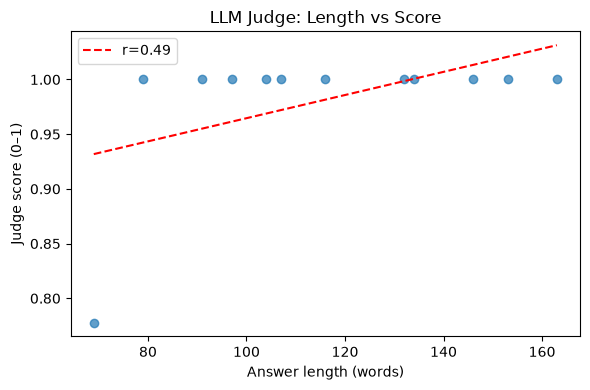

Saved to docs/judge_length_bias.png


In [19]:
# Length bias check
import matplotlib.pyplot as plt
import numpy as np

print("=== Length Bias Check ===")
all_judge = naive_scores + reranked_scores
lm = length_correlation_check(all_judge)
print(f"Pearson r (length vs score): {lm['pearson_r']:.3f}")
print(f"p-value: {lm['p_value']:.4f}")
if abs(lm['pearson_r']) > 0.3:
    print("⚠ Significant length bias (|r| > 0.3) — consider verbosity penalty in rubric")
else:
    print("✓ Length bias within acceptable range")

lengths = [len(r.answer.split()) for r in all_judge]
scores_arr = [r.score for r in all_judge]

plt.figure(figsize=(6, 4))
plt.scatter(lengths, scores_arr, alpha=0.7)
m, b = np.polyfit(lengths, scores_arr, 1)
xl = np.linspace(min(lengths), max(lengths), 100)
plt.plot(xl, m * xl + b, 'r--', label=f'r={lm["pearson_r"]:.2f}')
plt.xlabel("Answer length (words)")
plt.ylabel("Judge score (0–1)")
plt.title("LLM Judge: Length vs Score")
plt.legend()
plt.tight_layout()
plt.savefig('../docs/judge_length_bias.png', dpi=120)
plt.show()
print("Saved to docs/judge_length_bias.png")


### Written Question 6

*Your positional bias check shows a 22% flip rate. Describe exactly how you adjust the eval
procedure to produce trustworthy win rates. What statistical test would you use to determine
if one system is significantly better than another?*


In [20]:
# Final summary
print("=" * 58)
print("FINAL EVALUATION SUMMARY")
print("=" * 58)
print("\n1. Retrieval Benchmark (HotpotQA, Recall@k):")
for name, m in ablation_rows.items():
    print(f"   {name:<20} recall@5={m['recall@5']:.3f}")
print("\n2. RAGAS (Hybrid + Rerank):")
for metric, score in ragas_scores.items():
    print(f"   {metric:<25} {score:.3f}")
print(f"\n3. LLM-as-Judge:")
print(f"   Naive dense:      {n_mean:.3f}")
print(f"   Hybrid+rerank:    {r_mean:.3f}  ({r_mean - n_mean:+.3f})")
print(f"   Positional bias:  {bias['flip_rate']:.1%} flip rate")
print(f"   Length bias:      r={lm['pearson_r']:.3f}")


FINAL EVALUATION SUMMARY

1. Retrieval Benchmark (HotpotQA, Recall@k):
   BM25                 recall@5=0.000
   Dense                recall@5=0.000
   Hybrid RRF           recall@5=0.000
   Hybrid+Rerank        recall@5=0.000

2. RAGAS (Hybrid + Rerank):
   faithfulness              0.895
   answer_relevancy          0.968
   context_recall            1.000
   context_precision         0.468

3. LLM-as-Judge:
   Naive dense:      0.963
   Hybrid+rerank:    1.000  (+0.037)
   Positional bias:  100.0% flip rate
   Length bias:      r=0.494
